In [1]:
import os, json, random, time
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.models as models
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
from tqdm.notebook import tqdm
from sklearn.metrics import (
    precision_recall_fscore_support, roc_curve, auc as sk_auc
)

# PyTorch Vision utilities for IoU calculation
from torchvision.ops import box_iou

# Scikit-learn metrics for Detection performance
from sklearn.metrics import precision_recall_curve, f1_score, roc_curve, auc

# ---- Global constants ----
TOP5           = [1, 8, 7, 2, 9]
category_names = ['Short Sleeve Top', 'Trousers', 'Shorts', 'Long Sleeve Top', 'Skirt']
cat_to_idx     = {cat_id: i + 1 for i, cat_id in enumerate(TOP5)}
idx_to_name    = {0: 'Background', **{i+1: n for i, n in enumerate(category_names)}}
NUM_CLASSES    = len(TOP5) + 1
IMG_SIZE       = 256  # 256 vs 512: 4x fewer pixels → ~4x faster per epoch

DRIVE_SAVE = "/kaggle/working/VR_Mini_Project-1"
os.makedirs(DRIVE_SAVE, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_gpus = torch.cuda.device_count()
print('Device:', device)
print(f'GPUs available: {n_gpus}')
print('cat_to_idx:', cat_to_idx)

Device: cuda
GPUs available: 2
cat_to_idx: {1: 1, 8: 2, 7: 3, 2: 4, 9: 5}


In [2]:
class DeepFashionSegDataset(Dataset):
    """
    Returns:
      image : FloatTensor [3, H, W]  (normalised)
      mask  : LongTensor  [H, W]     (pixel class labels 0..NUM_CLASSES-1)
    """

    IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    def __init__(self, image_dir, anno_dir, img_size=IMG_SIZE, augment=False):
        self.image_dir = image_dir
        self.img_size  = img_size
        self.augment   = augment
        self.images    = sorted([f for f in os.listdir(image_dir) if f.endswith('.jpg')])

        # Pre-parse annotation JSON dicts (lightweight — strings/ints only, no pixel arrays)
        self.annos = []
        for img_name in self.images:
            anno_path = os.path.join(anno_dir, img_name.replace('.jpg', '.json'))
            if os.path.exists(anno_path):
                with open(anno_path) as f:
                    self.annos.append(json.load(f))
            else:
                self.annos.append({})

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        data     = self.annos[idx]

        # Load + resize image with cv2 (faster than PIL for JPEG)
        img = cv2.imread(os.path.join(self.image_dir, img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        H0, W0 = img.shape[:2]
        img = cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)

        # Build mask at original resolution, then resize once
        seg_mask = np.zeros((H0, W0), dtype=np.uint8)
        for key in data:
            if not key.startswith('item'): continue
            cat_id = data[key]['category_id']
            if cat_id not in cat_to_idx: continue
            label = cat_to_idx[cat_id]
            for poly in data[key]['segmentation']:
                pts = np.array(poly, dtype=np.float32).reshape(-1, 2).astype(np.int32)
                cv2.fillPoly(seg_mask, [np.ascontiguousarray(pts)], int(label))
        seg_mask = cv2.resize(seg_mask, (self.img_size, self.img_size),
                              interpolation=cv2.INTER_NEAREST)

        # Augmentation
        if self.augment and random.random() < 0.5:
            img      = img[:, ::-1, :].copy()
            seg_mask = seg_mask[:, ::-1].copy()

        # Normalise: HWC uint8 → CHW float32
        img_t = torch.from_numpy(img.copy()).permute(2, 0, 1).float().div_(255.0)
        mean  = torch.as_tensor(self.IMAGENET_MEAN).view(3, 1, 1)
        std   = torch.as_tensor(self.IMAGENET_STD).view(3, 1, 1)
        img_t = img_t.sub_(mean).div_(std)

        mask_t = torch.from_numpy(seg_mask.astype(np.int64))
        return img_t, mask_t, img_name

In [3]:
import gc  # needed for VRAM cleanup

BASE = "/kaggle/input/datasets/sasank93/vr-mini-project-pruned"

test_ds    = DeepFashionSegDataset(f"{BASE}/pruned_test/images",
                                   f"{BASE}/pruned_test/annos",  augment=False)

_nw = 4
# FIX: prefetch_factor reduced 3→2 to avoid overfilling pinned CPU/GPU memory
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False,
                          num_workers=_nw, pin_memory=True,
                          persistent_workers=True, prefetch_factor=2)

In [4]:
import shutil

DRIVE_SAVE = "/kaggle/working/VR_Mini_Project-1"
shutil.copy(
    "/kaggle/input/datasets/sasank2035/unet-weights-scratch/unet_scratch.pth",
    f"{DRIVE_SAVE}/unet_scratch.pth"
)

'/kaggle/working/VR_Mini_Project-1/unet_scratch.pth'

In [5]:
import shutil

DRIVE_SAVE = "/kaggle/working/VR_Mini_Project-1"
shutil.copy(
    "/kaggle/input/datasets/sasank2035/unet-weights-transfer/unet_transfer.pth",
    f"{DRIVE_SAVE}/unet_transfer.pth"
)

'/kaggle/working/VR_Mini_Project-1/unet_transfer.pth'

In [6]:
class ConvBnRelu(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class DecoderBlock(nn.Module):
    def __init__(self, in_c, skip_c, out_c):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_c, out_c, kernel_size=2, stride=2)
        self.conv = ConvBnRelu(out_c + skip_c, out_c)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        return self.conv(torch.cat([x, skip], dim=1))


class UNetResNet34(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super().__init__()
        enc = models.resnet34(
            weights=models.ResNet34_Weights.DEFAULT if pretrained else None)
        self.enc0       = nn.Sequential(enc.conv1, enc.bn1, enc.relu)
        self.pool       = enc.maxpool
        self.enc1       = enc.layer1
        self.enc2       = enc.layer2
        self.enc3       = enc.layer3
        self.enc4       = enc.layer4
        self.bottleneck = ConvBnRelu(512, 512)
        self.dec4       = DecoderBlock(512, 256, 256)
        self.dec3       = DecoderBlock(256, 128, 128)
        self.dec2       = DecoderBlock(128,  64,  64)
        self.dec1       = DecoderBlock( 64,  64,  64)
        self.dec0_conv  = ConvBnRelu(64, 32)
        self.head       = nn.Conv2d(32, num_classes, kernel_size=1)

    def forward(self, x):
        s0 = self.enc0(x)
        s1 = self.enc1(self.pool(s0))
        s2 = self.enc2(s1)
        s3 = self.enc3(s2)
        s4 = self.enc4(s3)
        x  = self.bottleneck(s4)
        x  = self.dec4(x, s3)
        x  = self.dec3(x, s2)
        x  = self.dec2(x, s1)
        x  = self.dec1(x, s0)
        x  = F.interpolate(x, scale_factor=2, mode='bilinear', align_corners=False)
        x  = self.dec0_conv(x)
        return self.head(x)


_m = UNetResNet34(NUM_CLASSES, pretrained=False)
_x = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
_o = _m(_x)
print('Output shape:', _o.shape)  # expect [2, 6, 256, 256]
del _m, _x, _o

Output shape: torch.Size([2, 6, 256, 256])


In [7]:
model_scratch = UNetResNet34(NUM_CLASSES, pretrained=False).to(device)
model_scratch.load_state_dict(torch.load(f"{DRIVE_SAVE}/unet_scratch.pth", map_location=device))
if n_gpus > 1:
    model_scratch = nn.DataParallel(model_scratch)
model_scratch.eval()


DataParallel(
  (module): UNetResNet34(
    (enc0): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (enc1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, mome

In [8]:
model_transfer = UNetResNet34(NUM_CLASSES, pretrained=False).to(device)
model_transfer.load_state_dict(torch.load(f"{DRIVE_SAVE}/unet_transfer.pth", map_location=device))
if n_gpus > 1:
    model_transfer = nn.DataParallel(model_transfer)
model_transfer.eval()

DataParallel(
  (module): UNetResNet34(
    (enc0): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (enc1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, mome


--- Transfer Learning Model Evaluation ---
Running U-Net evaluation...


  0%|          | 0/676 [00:00<?, ?it/s]


SEGMENTATION METRICS  (IoU & Dice per class)
  Background             IoU: 0.9082 | Dice: 0.9519
  Short Sleeve Top       IoU: 0.6359 | Dice: 0.7774
  Trousers               IoU: 0.6506 | Dice: 0.7883
  Shorts                 IoU: 0.5844 | Dice: 0.7377
  Long Sleeve Top        IoU: 0.5058 | Dice: 0.6718
  Skirt                  IoU: 0.5346 | Dice: 0.6967

  mIoU      : 0.6366
  Mean Dice : 0.7706

PIXEL-LEVEL DETECTION METRICS  (AUC / AP / F1 per class)
  Background             AP: 0.9996 | F1: 0.9885 | AUC: 0.9991
  Short Sleeve Top       AP: 0.9287 | F1: 0.8631 | AUC: 0.9887


/tmp/ipykernel_24/1714824993.py:121: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap         = np.trapz(precision, recall)
/tmp/ipykernel_24/1714824993.py:121: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap         = np.trapz(precision, recall)


  Trousers               No positive pixels — skipped
  Shorts                 AP: 0.8911 | F1: 0.9031 | AUC: 0.9987
  Long Sleeve Top        No positive pixels — skipped
  Skirt                  AP: 0.7745 | F1: 0.1350 | AUC: 0.9918

  mAP       : 0.8985
  Macro F1  : 0.7224
  Mean AUC  : 0.9946


/tmp/ipykernel_24/1714824993.py:121: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap         = np.trapz(precision, recall)
/tmp/ipykernel_24/1714824993.py:121: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap         = np.trapz(precision, recall)


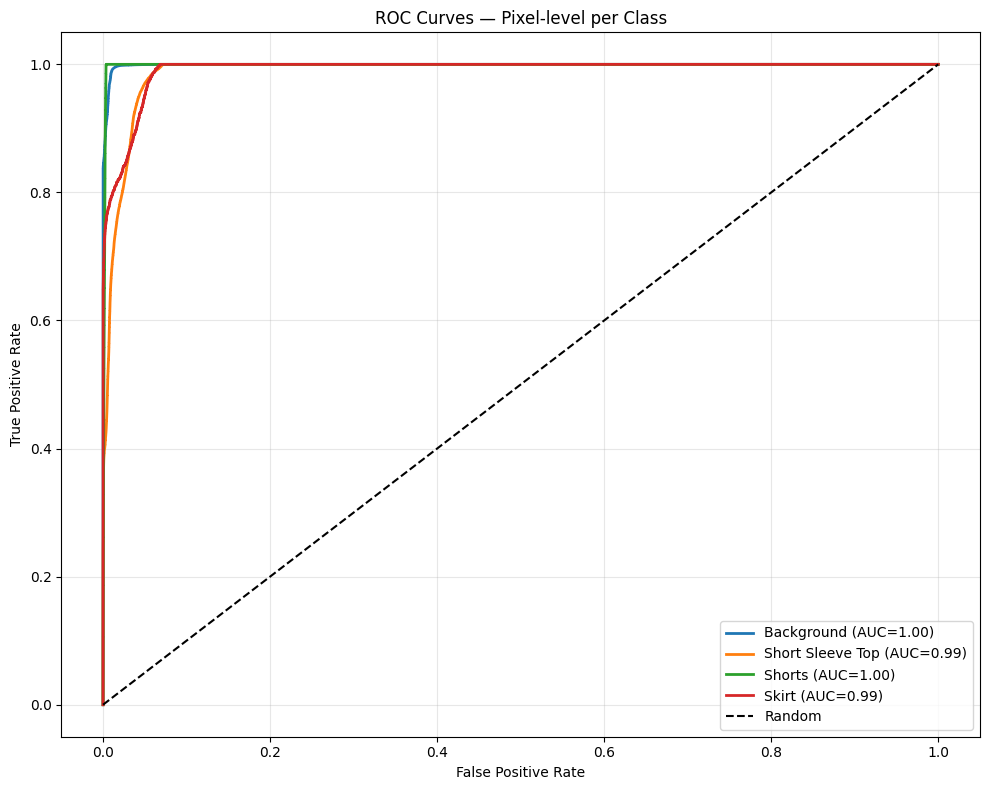


--- Scratch Model Evaluation ---
Running U-Net evaluation...


  0%|          | 0/676 [00:00<?, ?it/s]


SEGMENTATION METRICS  (IoU & Dice per class)
  Background             IoU: 0.8787 | Dice: 0.9354
  Short Sleeve Top       IoU: 0.5238 | Dice: 0.6875
  Trousers               IoU: 0.5726 | Dice: 0.7282
  Shorts                 IoU: 0.5276 | Dice: 0.6908
  Long Sleeve Top        IoU: 0.3720 | Dice: 0.5423
  Skirt                  IoU: 0.4125 | Dice: 0.5841

  mIoU      : 0.5479
  Mean Dice : 0.6947

PIXEL-LEVEL DETECTION METRICS  (AUC / AP / F1 per class)
  Background             AP: 0.9995 | F1: 0.9892 | AUC: 0.9992
  Short Sleeve Top       AP: 0.8124 | F1: 0.8073 | AUC: 0.9747
  Trousers               No positive pixels — skipped


/tmp/ipykernel_24/1714824993.py:121: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap         = np.trapz(precision, recall)
/tmp/ipykernel_24/1714824993.py:121: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap         = np.trapz(precision, recall)
/tmp/ipykernel_24/1714824993.py:121: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap         = np.trapz(precision, recall)


  Shorts                 AP: 0.9431 | F1: 0.8280 | AUC: 0.9991
  Long Sleeve Top        No positive pixels — skipped
  Skirt                  AP: 0.9434 | F1: 0.6685 | AUC: 0.9996

  mAP       : 0.9246
  Macro F1  : 0.8233
  Mean AUC  : 0.9931


/tmp/ipykernel_24/1714824993.py:121: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap         = np.trapz(precision, recall)


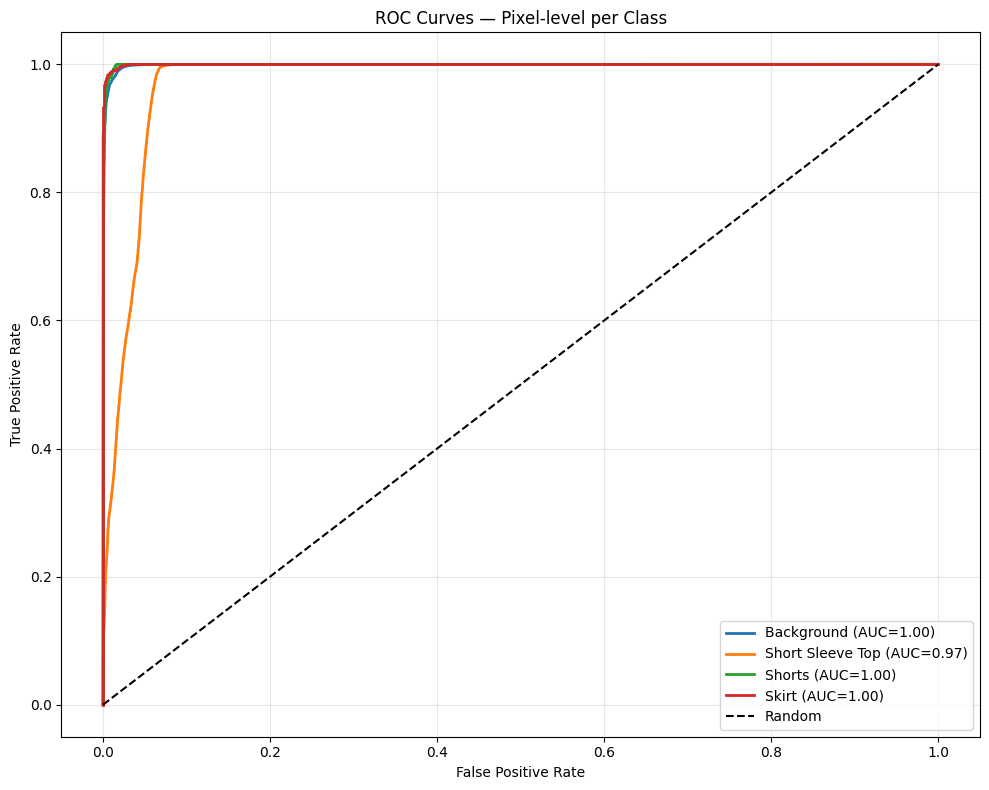

In [9]:
def evaluate_unet(model, loader, device, idx_to_name, threshold=0.5):
    """
    Evaluation function for UNetResNet34 on DeepFashion segmentation.

    Expects loader to yield: (images, masks, img_names)
      - images : FloatTensor [B, 3, H, W]  (ImageNet-normalised)
      - masks  : LongTensor  [B, H, W]     (pixel class labels 0..NUM_CLASSES-1)

    Model outputs: logits [B, NUM_CLASSES, H, W]
    idx_to_name: {0: 'Background', 1: 'Short Sleeve Top', ...}  (NUM_CLASSES=6 entries)
    """
    model.eval()
    num_classes = len(idx_to_name)   # 6 (background + 5 clothing)

    # Segmentation accumulators (over all matched pixels)
    intersection = {i: 0.0 for i in range(num_classes)}
    union        = {i: 0.0 for i in range(num_classes)}
    dice_num     = {i: 0.0 for i in range(num_classes)}
    dice_den     = {i: 0.0 for i in range(num_classes)}

    # Pixel-level scores for AUC / AP (sampled to avoid OOM)
    all_scores = {i: [] for i in range(num_classes)}
    all_tp     = {i: [] for i in range(num_classes)}

    MAX_PIXELS_PER_CLASS = 200_000   # cap to keep memory sane
    rng = np.random.default_rng(42)

    print("Running U-Net evaluation...")
    with torch.no_grad():
        for images, masks, _ in tqdm(loader):
            images = images.to(device)            # [B, 3, H, W]
            masks  = masks.to(device)             # [B, H, W]  — long

            logits = model(images)                # [B, 6, H, W]
            probs  = torch.softmax(logits, dim=1) # [B, 6, H, W]
            preds  = torch.argmax(probs,  dim=1)  # [B, H, W]

            for b in range(images.size(0)):
                gt_b   = masks[b].cpu()           # [H, W]
                pred_b = preds[b].cpu()           # [H, W]
                prob_b = probs[b].cpu()           # [6, H, W]

                for c in range(num_classes):
                    gt_c   = (gt_b   == c).float()   # [H, W]
                    pred_c = (pred_b == c).float()   # [H, W]
                    conf_c = prob_b[c]               # [H, W] — softmax score

                    # ── Segmentation metrics ──
                    inter = (pred_c * gt_c).sum().item()
                    uni   = ((pred_c + gt_c) > 0).float().sum().item()

                    intersection[c] += inter
                    union[c]        += uni
                    dice_num[c]     += 2 * inter
                    dice_den[c]     += pred_c.sum().item() + gt_c.sum().item()

                    # ── Pixel scores for AUC/AP (reservoir-sampled) ──
                    gt_flat   = gt_c.numpy().flatten().astype(np.int32)
                    conf_flat = conf_c.numpy().flatten()
                    tp_flat   = ((pred_c.numpy().flatten() == 1) & (gt_flat == 1)).astype(np.int32)

                    # Only sample if we still need more pixels for this class
                    current = len(all_scores[c])
                    if current < MAX_PIXELS_PER_CLASS:
                        budget = MAX_PIXELS_PER_CLASS - current
                        if len(conf_flat) > budget:
                            idx = rng.choice(len(conf_flat), budget, replace=False)
                            conf_flat = conf_flat[idx]
                            tp_flat   = tp_flat[idx]
                        all_scores[c].extend(conf_flat.tolist())
                        all_tp[c].extend(tp_flat.tolist())

    # ══════════════════════════════════════════════════
    # SEGMENTATION METRICS
    # ══════════════════════════════════════════════════
    print("\n" + "="*60)
    print("SEGMENTATION METRICS  (IoU & Dice per class)")
    print("="*60)

    iou_list, dice_list = [], []
    for c in range(num_classes):
        name = idx_to_name[c]
        if union[c] == 0:
            print(f"  {name:<22} IoU: N/A    | Dice: N/A")
            continue
        iou  = intersection[c] / (union[c]    + 1e-6)
        dice = dice_num[c]     / (dice_den[c] + 1e-6)
        iou_list.append(iou)
        dice_list.append(dice)
        print(f"  {name:<22} IoU: {iou:.4f} | Dice: {dice:.4f}")

    print(f"\n  mIoU      : {np.mean(iou_list):.4f}")
    print(f"  Mean Dice : {np.mean(dice_list):.4f}")

    # ══════════════════════════════════════════════════
    # PIXEL-LEVEL DETECTION METRICS (AUC, AP, F1)
    # ══════════════════════════════════════════════════
    print("\n" + "="*60)
    print("PIXEL-LEVEL DETECTION METRICS  (AUC / AP / F1 per class)")
    print("="*60)

    ap_list, auc_list, f1_list = [], [], []
    plt.figure(figsize=(10, 8))

    for c in range(num_classes):
        name   = idx_to_name[c]
        scores = np.array(all_scores[c])
        tps    = np.array(all_tp[c])

        if len(scores) == 0 or tps.sum() == 0:
            print(f"  {name:<22} No positive pixels — skipped")
            continue

        # Precision-Recall → AP
        sorted_idx = np.argsort(-scores)
        tps_s      = tps[sorted_idx]
        cum_tp     = np.cumsum(tps_s)
        cum_fp     = np.cumsum(1 - tps_s)
        precision  = cum_tp / (cum_tp + cum_fp + 1e-6)
        recall     = cum_tp / (tps.sum() + 1e-6)
        ap         = np.trapz(precision, recall)
        ap_list.append(ap)

        # F1 at given threshold
        pred_binary = (scores >= threshold).astype(int)
        f1 = f1_score(tps, pred_binary, zero_division=0)
        f1_list.append(f1)

        # ROC-AUC
        if len(np.unique(tps)) > 1:
            fpr, tpr, _ = roc_curve(tps, scores)
            roc_auc     = auc(fpr, tpr)
            plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={roc_auc:.2f})")
        else:
            roc_auc = 0.0
        auc_list.append(roc_auc)

        print(f"  {name:<22} AP: {ap:.4f} | F1: {f1:.4f} | AUC: {roc_auc:.4f}")

    if ap_list:
        print(f"\n  mAP       : {np.mean(ap_list):.4f}")
        print(f"  Macro F1  : {np.mean(f1_list):.4f}")
        print(f"  Mean AUC  : {np.mean(auc_list):.4f}")

    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves — Pixel-level per Class")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# ── Run both models ──
print("\n--- Transfer Learning Model Evaluation ---")
evaluate_unet(model_transfer, test_loader, device, idx_to_name)

print("\n--- Scratch Model Evaluation ---")
evaluate_unet(model_scratch, test_loader, device, idx_to_name)